# 05 - Visualization
Spatial predictions, error maps, temporal trends

In [1]:
!pip install -q matplotlib cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/fishing_project/"

Mounted at /content/drive


In [3]:
# Load predictions
y_test = np.load(DATA_DIR + 'y_test.npy')
preds = np.load(DATA_DIR + 'predictions.npy')

# Coordinate system
LAT_MIN, LAT_MAX = 7, 20
LON_MIN, LON_MAX = 114, 120

In [4]:
# Custom colormap
cmap = LinearSegmentedColormap.from_list(
    'fishing',
    ['#000033', '#0000FF', '#FF00FF', '#FF0000']
)

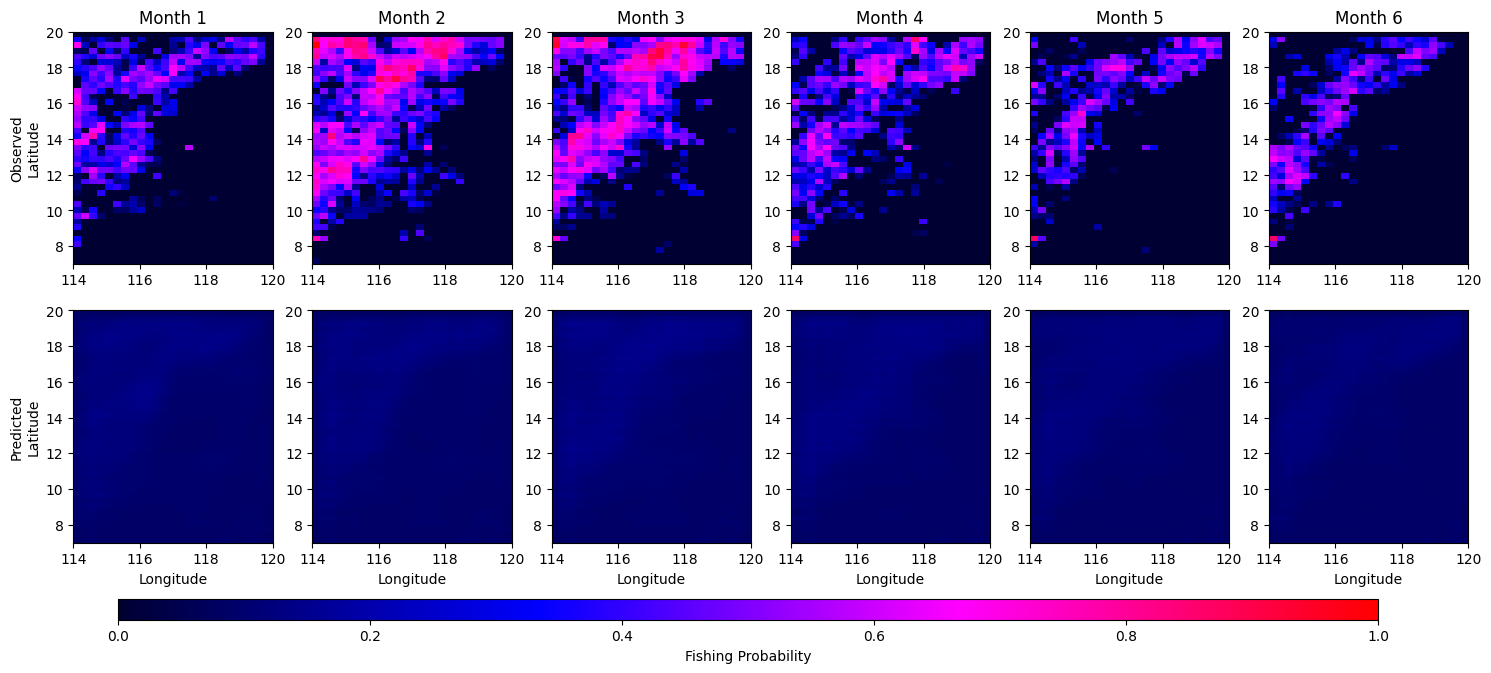

In [9]:
# 1. Observed vs Predicted (6 samples)
n_samples = min(6, len(y_test))
fig, axes = plt.subplots(2, n_samples, figsize=(18, 7))  # slightly taller for colorbar room

for i in range(n_samples):
    # Observed
    axes[0, i].imshow(
        y_test[i, :, :, 0],
        extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
        cmap=cmap,
        vmin=0, vmax=1,
        aspect='auto',
        origin='lower'
    )
    axes[0, i].set_title(f'Month {i+1}')
    if i == 0:
        axes[0, i].set_ylabel('Observed\nLatitude')

    # Predicted
    im = axes[1, i].imshow(   # ← capture 'im' from any subplot (all share same scale)
        preds[i, :, :, 0],
        extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
        cmap=cmap,
        vmin=0, vmax=1,
        aspect='auto',
        origin='lower'
    )
    if i == 0:
        axes[1, i].set_ylabel('Predicted\nLatitude')
    axes[1, i].set_xlabel('Longitude')

# Reserve space at the bottom for the colorbar
fig.subplots_adjust(bottom=0.15)

# Manually place colorbar axis BELOW all subplots
# [left, bottom, width, height] in figure-fraction coordinates
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Fishing Probability')

plt.savefig(DATA_DIR + 'obs_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()


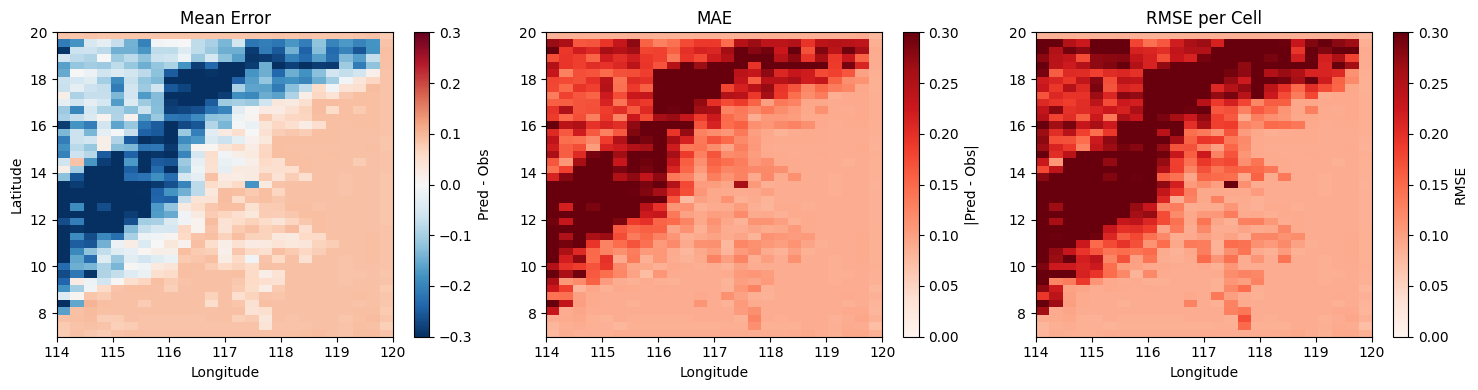

In [6]:
# 2. Error Analysis
error = preds - y_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean error
im1 = axes[0].imshow(
    error.mean(axis=0)[:, :, 0],
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap='RdBu_r',
    vmin=-0.3, vmax=0.3,
    aspect='auto',
    origin='lower'
)
axes[0].set_title('Mean Error')
axes[0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0], label='Pred - Obs')

# MAE
im2 = axes[1].imshow(
    np.abs(error).mean(axis=0)[:, :, 0],
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap='Reds',
    vmin=0, vmax=0.3,
    aspect='auto',
    origin='lower'
)
axes[1].set_title('MAE')
plt.colorbar(im2, ax=axes[1], label='|Pred - Obs|')

# RMSE per cell
rmse_spatial = np.sqrt((error**2).mean(axis=0)[:, :, 0])
im3 = axes[2].imshow(
    rmse_spatial,
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
    cmap='Reds',
    vmin=0, vmax=0.3,
    aspect='auto',
    origin='lower'
)
axes[2].set_title('RMSE per Cell')
plt.colorbar(im3, ax=axes[2], label='RMSE')

for ax in axes:
    ax.set_xlabel('Longitude')

plt.tight_layout()
plt.savefig(DATA_DIR + 'error_maps.png', dpi=300)
plt.show()

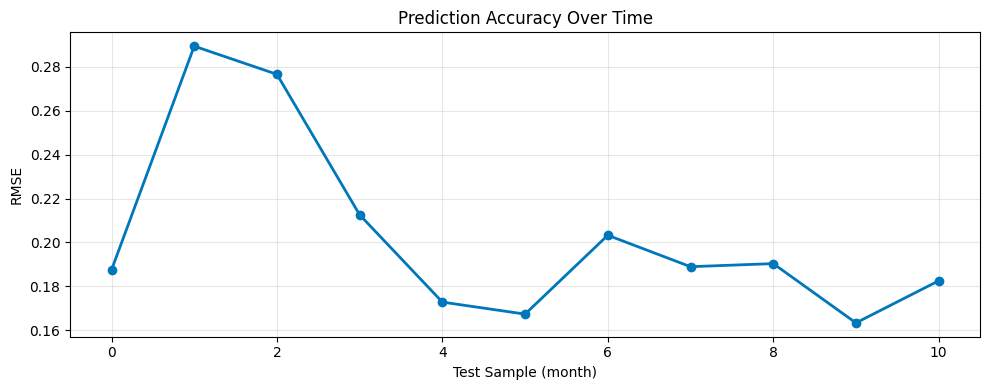

In [7]:
# 3. Temporal Performance
from sklearn.metrics import mean_squared_error

monthly_rmse = []
for i in range(len(y_test)):
    yi = np.nan_to_num(y_test[i].flatten(), nan=0.0)
    pi = np.nan_to_num(preds[i].flatten(), nan=0.0)
    rmse = np.sqrt(mean_squared_error(yi, pi))
    monthly_rmse.append(rmse)

plt.figure(figsize=(10, 4))
plt.plot(monthly_rmse, marker='o', linewidth=2, markersize=6, color='#0077BB')
plt.xlabel('Test Sample (month)')
plt.ylabel('RMSE')
plt.title('Prediction Accuracy Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR + 'temporal_performance.png', dpi=300, bbox_inches='tight')
plt.show()


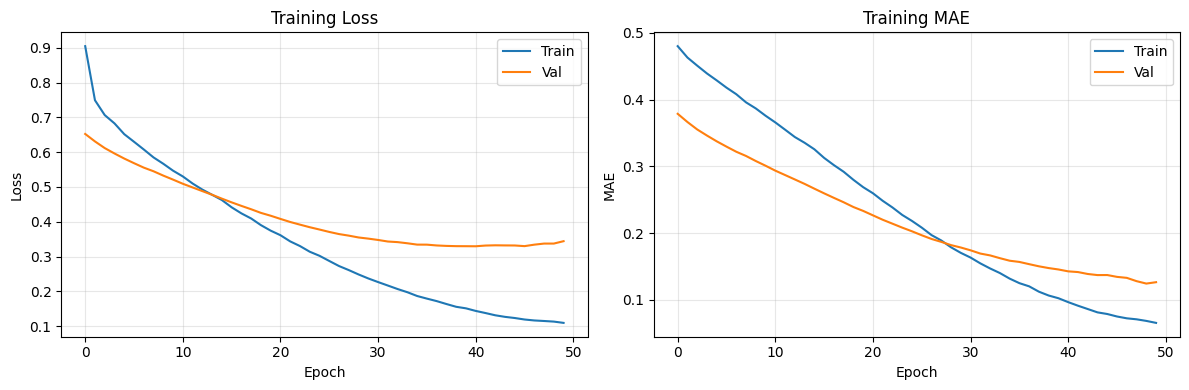


✅ All visualizations saved


In [8]:
# 4. Training History
import json
with open(DATA_DIR + 'training_history.json', 'r') as f:
    history = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history['loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(history['mae'], label='Train')
ax2.plot(history['val_mae'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Training MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR + 'training_curves.png', dpi=300)
plt.show()

print("\n✔ All visualizations saved")